In [3]:
# -*- coding: utf-8 -*-
"""
multi_ticker_vol_signal_db.py  (FIXED VERSION — all 8 fixes)
=============================================================
FIX 1 — Stage 6: Clip CalibVol_Scaled to SCALE_FLOOR
         Prevents exact zero from making a ticker auto-win Monthly_Rank=1.

FIX 2 — Stage 6: Guard zero-range denominator
         When roll_max - roll_min < 1e-6, replace with NaN to avoid inf/spurious zeros.

FIX 3 — Stage 7: EWMA adjust=True
         Removes cold-start bias where the EWMA anchors on the first (SCALE_FLOOR) value.

FIX 4 — Stage 7: Monthly rolling min_periods 2 → 3
         Reduces influence of a single boundary value in the 4-week rolling mean.

FIX 5 — Phase 3: Minimum monthly rows = 24
         Tickers with too little history (IRFC=5, SBICARD=12) are excluded entirely.

FIX 6 — Phase 4: Reject zero signals in _get_signal
         Defensive backstop so any future zero is treated as "no signal".

FIX 7 — Stage 7: Drop first MONTHLY_WARMUP rows per ticker
         Even after Fixes 1-6, the very first 1-3 monthly rows per ticker may carry
         residual cold-start artefacts:
           • SBILIFE Sep-2022:   Smooth=SCALE_FLOOR (0.0001), Monthly=NaN
             → Only 1 weekly CalibVol_Scaled obs exists at first monthly sample;
               EWMA = that single obs = SCALE_FLOOR; rolling(4, min_periods=3) = NaN.
           • HDFCLIFE Feb-2023:  Smooth valid, Monthly=NaN  (same rolling window issue)
           • ADANIGREEN Aug-2023: Smooth valid, Monthly=NaN  (same rolling window issue)
         Dropping the first MONTHLY_WARMUP=3 monthly rows ensures the rolling window
         has had time to accumulate ≥3 valid weekly observations (needed by Fix 4),
         and the EWMA has incorporated enough history to be meaningful.
         Cost: 3 fewer monthly rows per ticker (negligible given history depth).

FIX 8 — Phase 4: Fill-next-valid substitution
         User's suggestion: if a selected ticker's opposite-method signal is blank,
         skip it and promote the next-ranked eligible ticker that has both signals.
         Implementation:
           • _fill_portfolio() walks down the ranked list preferring tickers with
             both signals populated.
           • A first pass collects tickers with both signals valid.
           • If fewer than TOP_N_LOW_VOL such tickers exist, a second pass fills
             remaining slots from single-signal tickers (fallback, rarely triggered
             after Fixes 1-7).
           • The output now records whether each pick was a direct pick or a
             substitution, via a new "Substituted" column.
"""

import sys
import warnings
import numpy as np
import pandas as pd
from sqlalchemy            import text
from scipy.stats           import skew, kurtosis
from scipy.stats.mstats    import winsorize
from scipy.optimize        import curve_fit
from sklearn.preprocessing import QuantileTransformer

warnings.filterwarnings("ignore")

# ─── USER CONFIGURATION ───────────────────────────────────────────────────────
DB_CONFIG        = r"D:\Macro Research\db_config.yaml"
DB_NAME          = "wm_price_db"
DB_TABLE         = "public.merged_historical_data_with_rics"
DB_DATE_COL      = "date"
DB_TICKER_COL    = "ticker"
DB_CLOSE_COL     = "close"

MCAP_FILE        = r"D:\Linear Model\mcap_based_universe_202602251340.csv"
REBAL_FILE       = r"D:\Linear Model\data\RSI\Final\NSEI\W_allRebal_200226.xlsx"
MASS_PATH        = r"D:\Linear Model\Python_Scripts\mass.py"

SUPPLEMENTARY_PRICE_FILE = r"D:\Linear Model\data\Universe\final_eq_2026-02-26-18-30-05_long_format.csv"
RIC_TO_TICKER = {
    "GLSM.NS^D20": "GSKCONS",
    "HDFC.NS^G23": "HDFC",
}

SIGNAL_START        = pd.Timestamp("2020-01-01")
PRICE_HISTORY_START = pd.Timestamp("2000-01-01")

TOP_N_UNIVERSE   = 50
TOP_N_LOW_VOL    = 10
MIN_PRICE_ROWS   = 200

# FIX 5 — minimum monthly rows before a ticker enters Phase 4 ranking
MIN_MONTHLY_ROWS = 24

# FIX 1 — floor for CalibVol_Scaled to prevent exact-zero boundary artefacts
SCALE_FLOOR      = 1e-4

# FIX 7 — number of first monthly rows to drop per ticker (cold-start warmup)
# These early rows have ≤2 weekly CalibVol_Scaled observations in the rolling
# window (insufficient for min_periods=3 Monthly) and a not-yet-stable EWMA.
MONTHLY_WARMUP   = 3

INSTRUMENT_TYPES = {"ordinary"}

OUTPUT_MONTHLY   = r"monthly_low_vol_selection.xlsx"
OUTPUT_CACHE     = r"ticker_signals_cache.xlsx"


# ══════════════════════════════════════════════════════════════════════════════
#  SHARED HELPERS
# ══════════════════════════════════════════════════════════════════════════════

def winsorize_series(s: pd.Series, lower=0.01, upper=0.01) -> pd.Series:
    if s.isnull().all():
        return s
    out    = s.copy()
    non_na = out.dropna()
    out.loc[non_na.index] = winsorize(non_na, limits=[lower, upper])
    return out


def exp_func(x, a, b):
    return a * np.exp(b * x)


def sep(title=""):
    w = 65
    if title:
        print(f"\n{'─'*w}\n  {title}\n{'─'*w}")
    else:
        print("─" * w)


# ══════════════════════════════════════════════════════════════════════════════
#  PHASE 1 ─ UNIVERSE CONSTRUCTION  (unchanged)
# ══════════════════════════════════════════════════════════════════════════════

# ══════════════════════════════════════════════════════════════════════════════
#  PHASE 1 ─ UNIVERSE CONSTRUCTION
# ══════════════════════════════════════════════════════════════════════════════

def build_monthly_universes(mcap_file: str) -> tuple[dict, list]:
    sep("PHASE 1 — Building monthly top-50 universes from mcap file")

    with open(mcap_file, "r", encoding="utf-8", errors="replace") as _f:
        _first_line = _f.readline()
    _sep = "," if _first_line.count(",") > _first_line.count("\t") else "\t"
    print(f"  Detected separator: {repr(_sep)}")

    mcap = pd.read_csv(mcap_file, sep=_sep, low_memory=False)
    mcap.columns = mcap.columns.str.strip().str.lower()

    date_col = next((c for c in ["date", "Date", "DATE"] if c in mcap.columns), None)
    if date_col is None:
        raise ValueError(f"No date column found. Columns: {mcap.columns.tolist()}")

    mcap = mcap.rename(columns={date_col: "Date"})
    mcap["Date"] = pd.to_datetime(mcap["Date"], dayfirst=True, errors="coerce")

    if "instrument_class" in mcap.columns:
        mcap = mcap[mcap["instrument_class"].str.lower().isin(INSTRUMENT_TYPES)]

    mcap["mcap"] = pd.to_numeric(mcap["mcap"], errors="coerce")

    if "ticker" in mcap.columns:
        ID_COL = "ticker"
    elif "ric" in mcap.columns:
        ID_COL = "ric"
    else:
        raise ValueError(f"No ticker/ric column. Columns: {mcap.columns.tolist()}")
    print(f"  Using '{ID_COL}' column as ticker identifier")

    mcap = mcap.dropna(subset=["mcap", "Date", ID_COL])
    mcap[ID_COL] = mcap[ID_COL].astype(str).str.strip()
    if "ric" in mcap.columns and ID_COL != "ric":
        mcap["ric"] = mcap["ric"].astype(str).str.strip()

    # 1. Get all valid dates
    raw_snap_dates = [d for d in sorted(mcap["Date"].unique())
                      if pd.Timestamp(d) >= SIGNAL_START]

    # 2. FIX: Group by Year-Month and keep ONLY the last date of each month
    dates_s = pd.Series(pd.to_datetime(raw_snap_dates))
    monthly_snap_dates = dates_s.groupby(dates_s.dt.to_period("M")).max().tolist()

    monthly_universes: dict = {}

    # 3. Loop over the filtered month-end dates instead of all raw dates
    for snap_date in monthly_snap_dates:
        snap  = mcap[mcap["Date"] == snap_date].sort_values("mcap", ascending=False)
        top50 = snap[ID_COL].dropna().tolist()[:TOP_N_UNIVERSE]
        if top50:
            monthly_universes[pd.Timestamp(snap_date)] = top50

    all_unique_tickers = sorted(
        {t for tlist in monthly_universes.values() for t in tlist}
    )
    print(f"  Months in universe       : {len(monthly_universes)}")
    print(f"  Unique tickers (all-time): {len(all_unique_tickers)}")
    print(f"  Date range               : "
          f"{min(monthly_universes):%Y-%m-%d} → {max(monthly_universes):%Y-%m-%d}")
    print(f"\n  Sample tickers: {all_unique_tickers[:8]}")
    return monthly_universes, all_unique_tickers


# ══════════════════════════════════════════════════════════════════════════════
#  PHASE 2 ─ PRICE FETCH  (unchanged)
# ══════════════════════════════════════════════════════════════════════════════

def fetch_prices_from_db(all_unique_tickers, engine):
    sep("PHASE 2 — Fetching prices from PostgreSQL")
    print(f"  Tickers to query : {len(all_unique_tickers)}")
    print(f"  Sample            : {all_unique_tickers[:5]}")
    print(f"  Price history from: {PRICE_HISTORY_START.date()}")

    try:
        diag = pd.read_sql(
            text(f"SELECT DISTINCT {DB_TICKER_COL} AS ticker FROM {DB_TABLE} LIMIT 10"),
            engine,
        )
        print(f"  DB ticker sample  : {diag['ticker'].tolist()}")
    except Exception as _e:
        print(f"  ⚠ Diagnostic query failed: {_e}")

    print("  Running main query ... ", end="", flush=True)
    query = text(f"""
        SELECT {DB_DATE_COL} AS date, {DB_TICKER_COL} AS ticker, {DB_CLOSE_COL} AS close
        FROM  {DB_TABLE}
        WHERE {DB_TICKER_COL} = ANY(:tickers)
          AND {DB_DATE_COL}   >= :start_date
        ORDER BY {DB_DATE_COL}, {DB_TICKER_COL}
    """)
    df = pd.read_sql(query, engine,
                     params={"tickers"   : all_unique_tickers,
                             "start_date": PRICE_HISTORY_START.strftime("%Y-%m-%d")})
    print("done.")

    df["date"]  = pd.to_datetime(df["date"])
    df["close"] = pd.to_numeric(df["close"], errors="coerce")
    price_master = df.pivot(index="date", columns="ticker", values="close").sort_index()

    missing = sorted(set(all_unique_tickers) - set(price_master.columns))
    print(f"  price_master shape  : {price_master.shape}")
    print(f"  Date range          : "
          f"{price_master.index.min().date()} → {price_master.index.max().date()}")
    if missing:
        print(f"  ⚠  {len(missing)} tickers not found: {missing[:10]}"
              + (" ..." if len(missing) > 10 else ""))
    else:
        print(f"  ✅ All {len(all_unique_tickers)} tickers retrieved")
    return price_master, missing


def merge_supplementary_prices(price_master, missing_tickers):
    if not SUPPLEMENTARY_PRICE_FILE or not missing_tickers:
        return price_master, missing_tickers

    sep("PHASE 2c — Merging supplementary price file")
    print(f"  File            : {SUPPLEMENTARY_PRICE_FILE}")
    print(f"  Tickers to fill : {missing_tickers}")

    with open(SUPPLEMENTARY_PRICE_FILE, "r", encoding="utf-8", errors="replace") as _f:
        _first = _f.readline()
    _sep = "," if _first.count(",") > _first.count("\t") else "\t"

    supp = pd.read_csv(SUPPLEMENTARY_PRICE_FILE, sep=_sep, low_memory=False)
    supp.columns = supp.columns.str.strip().str.lower()
    supp["date"]   = pd.to_datetime(supp["date"], errors="coerce")
    supp["close"]  = pd.to_numeric(supp["close"], errors="coerce")
    supp = supp.dropna(subset=["date", "close", "ric"])
    supp = supp[supp["date"] >= PRICE_HISTORY_START]
    supp["ticker"] = supp["ric"].map(RIC_TO_TICKER)
    supp = supp.dropna(subset=["ticker"])

    missing_set = set(missing_tickers)
    supp = supp[supp["ticker"].isin(missing_set)]
    if supp.empty:
        print("  ⚠  No supplementary data matched missing tickers.")
        return price_master, missing_tickers

    supp_wide = supp.pivot_table(index="date", columns="ticker",
                                  values="close", aggfunc="last")
    full_idx  = price_master.index.union(supp_wide.index).sort_values()
    pm        = price_master.reindex(full_idx)
    sw        = supp_wide.reindex(full_idx)

    resolved = []
    for ticker in supp_wide.columns:
        if ticker in missing_set:
            pm[ticker] = sw[ticker]
            resolved.append(ticker)
            rows = supp[supp["ticker"] == ticker]
            print(f"  ✓  {ticker:<18}  "
                  f"{rows['date'].min().date()} → {rows['date'].max().date()}  "
                  f"({rows['close'].notna().sum()} rows)")

    still_missing = sorted(missing_set - set(resolved))
    print(f"  Resolved: {resolved}")
    if still_missing:
        print(f"  Still missing: {still_missing}")
    else:
        print(f"  ✅ All previously missing tickers resolved.")
    return pm, still_missing


def load_rebal_dates(engine, price_master):
    sep("PHASE 2b — Loading rebalancing dates")
    last_price_date = price_master.index.max()
    try:
        df = pd.read_sql("SELECT date FROM public.rebal_dates ORDER BY date", engine)
        df["date"] = pd.to_datetime(df["date"])
        rebal_dates = df.loc[
            (df["date"] >= PRICE_HISTORY_START) & (df["date"] <= last_price_date),
            "date",
        ].tolist()
        print(f"  Source: DB table 'public.rebal_dates'  ({len(rebal_dates)} dates)")
        return rebal_dates
    except Exception:
        pass

    rebal_raw = pd.read_excel(REBAL_FILE)
    rebal_raw["Date"] = pd.to_datetime(rebal_raw["Date"])
    rebal_dates = rebal_raw.loc[
        (rebal_raw["Date"] >= PRICE_HISTORY_START) &
        (rebal_raw["Date"] <= last_price_date),
        "Date",
    ].tolist()
    print(f"  Source: {REBAL_FILE}  ({len(rebal_dates)} dates)")
    return rebal_dates


# ══════════════════════════════════════════════════════════════════════════════
#  PHASE 3 ─ PER-TICKER VOLATILITY SIGNAL PIPELINE
# ══════════════════════════════════════════════════════════════════════════════

def _run_single_ticker_pipeline(ticker, price_master, all_rebal_dates, Match):
    """
    Full 7-stage vol-regime pipeline for one ticker.
    All 7 fixes (Fixes 1-7) applied here.
    """

    if ticker not in price_master.columns:
        return None

    close_s = price_master[[ticker]].dropna()
    if len(close_s) < MIN_PRICE_ROWS:
        return None

    first_px     = close_s.index[0]
    ticker_rebal = [d for d in all_rebal_dates
                    if d >= first_px + pd.DateOffset(days=90)]
    if len(ticker_rebal) < 52:
        return None

    # ── Stage 1 — Realized Variance ──────────────────────────────────────────
    rv_df = (close_s.pct_change().dropna() ** 2).rename(columns={ticker: "RV"})

    # ── Stage 2 — MASS motif matching ────────────────────────────────────────
    rows = []
    for date in ticker_rebal:
        try:
            mk  = Match(rv_df, date, windowSize=45, threshold=0.50)
            if mk.getDates().empty:
                continue
            reg = mk.getRegime()
            if reg.empty:
                continue
            for _, row in reg.head(5).iterrows():
                end_dt  = row["end"]
                fwd_end = end_dt + pd.DateOffset(months=1)
                mask    = (close_s.index > end_dt) & (close_s.index <= fwd_end)
                px      = close_s.loc[mask].iloc[:, 0]
                if len(px) < 5:
                    continue
                ret = px.pct_change().dropna()
                if len(ret) == 0:
                    continue
                rows.append({
                    "RebalDate"     : date,
                    "end"           : end_dt,
                    "dp"            : row["dp"],
                    "Vol_1M"        : ret.std(),
                    "MeanRet_1M"    : ret.mean(),
                    "RealizedVol_1M": float(np.sum(ret ** 2)),
                    "Skew_1M"       : skew(ret),
                    "Kurt_1M"       : kurtosis(ret, fisher=True),
                })
        except Exception:
            continue

    if not rows:
        return None

    top_reg       = pd.DataFrame(rows)
    top_reg["dp"] = winsorize(top_reg["dp"].values, limits=[0, 0.01])

    # ── Stage 3 — IDW + NW aggregation ───────────────────────────────────────
    def _idw(df, vcol, wcol="dp"):
        sub = df[[vcol, wcol]].dropna()
        if sub.empty:
            return np.nan
        inv_w = 1.0 / sub[wcol]
        w     = inv_w / inv_w.sum()
        return float(np.dot(sub[vcol], w))

    def _nw(df, vcol, wcol="dp", eta_factor=0.2):
        sub = df[[vcol, wcol]].dropna()
        if sub.empty:
            return np.nan
        eta = max(sub[wcol].mean() * eta_factor, 1e-5)
        w   = np.exp(-(sub[wcol] ** 2) / (2 * eta ** 2))
        w  /= w.sum()
        return float(np.dot(w, sub[vcol]))

    agg = (
        top_reg.groupby("RebalDate")
        .apply(lambda g: pd.Series({
            "WgtVol_1M"        : _idw(g, "Vol_1M"),
            "WgtMeanRet_1M"    : _idw(g, "MeanRet_1M"),
            "WgtRealizedVol_1M": _idw(g, "RealizedVol_1M"),
            "WgtSkew_1M"       : _idw(g, "Skew_1M"),
            "WgtKurt_1M"       : _idw(g, "Kurt_1M"),
        }))
        .reset_index()
        .sort_values("RebalDate")
        .reset_index(drop=True)
    )

    for col in ["WgtVol_1M", "WgtRealizedVol_1M"]:
        agg[col] = winsorize_series(agg[col])

    nw_rows = (
        top_reg.groupby("RebalDate")
        .apply(lambda g: _nw(g, "Vol_1M"))
        .rename("NW_Vol_1M")
        .reset_index()
    )
    nw_rows["NW_Vol_1M"] = winsorize_series(nw_rows["NW_Vol_1M"])

    def _obs_vol_fwd(date):
        fwd = date + pd.DateOffset(months=1)
        px  = close_s.loc[(close_s.index > date) & (close_s.index <= fwd)].iloc[:, 0]
        return px.pct_change().dropna().std() if len(px) >= 2 else np.nan

    nw_rows["Observed_Vol_1M"] = [_obs_vol_fwd(d) for d in nw_rows["RebalDate"]]
    nw_rows["Observed_Vol_1M"] = winsorize_series(nw_rows["Observed_Vol_1M"])

    agg = agg.set_index("RebalDate")
    agg["Observed_Vol_1M"] = nw_rows.set_index("RebalDate")["Observed_Vol_1M"]
    agg = agg.dropna().reset_index()

    if len(agg) < 52:
        return None

    # ── Stage 4 — Observed-vol pool ───────────────────────────────────────────
    px_ret     = close_s.iloc[:, 0].pct_change().dropna()
    px_roll    = px_ret.rolling(30).std().dropna()
    px_df      = px_roll.to_frame("rv30")
    pool_dates = [d for d in all_rebal_dates
                  if px_df.index.min() <= d <= px_df.index.max()]

    def _obs_vol_pool(date):
        fwd = date + pd.DateOffset(months=1)
        px  = close_s.loc[(close_s.index > date) & (close_s.index <= fwd)].iloc[:, 0]
        return px.pct_change().dropna().std() if len(px) >= 2 else np.nan

    obs_pool = pd.DataFrame(
        {"Observed_Vol_1M": [_obs_vol_pool(d) for d in pool_dates]},
        index=pd.to_datetime(pool_dates),
    ).dropna()

    if len(obs_pool) < 30:
        return None

    # ── Stage 5 — Expanding quantile bucketing ────────────────────────────────
    N_BUCKETS    = 30
    bucket_edges = np.linspace(0, 1, N_BUCKETS + 1)
    agg["VolBucket"]          = np.nan
    agg["Observed_VolBucket"] = np.nan

    def _assign_bucket(vol, qt, p5, p95):
        vc = np.clip(vol, p5, p95)
        t  = qt.transform(np.array([[vc]])).item()
        for i in range(len(bucket_edges) - 1):
            if bucket_edges[i] <= t < bucket_edges[i + 1]:
                return i + 1
        return N_BUCKETS if t >= bucket_edges[-1] else np.nan

    for idx, row in agg.iterrows():
        date    = row["RebalDate"]
        past    = obs_pool.loc[obs_pool.index < date, "Observed_Vol_1M"]
        if len(past) < N_BUCKETS:
            continue
        p5, p95 = np.percentile(past, [0, 95])
        clipped = np.clip(past, p5, p95)
        qt      = QuantileTransformer(
                      output_distribution="uniform",
                      n_quantiles=min(len(clipped), 1000),
                  )
        qt.fit_transform(clipped.values.reshape(-1, 1))
        agg.at[idx, "VolBucket"]          = _assign_bucket(row["WgtVol_1M"],       qt, p5, p95)
        agg.at[idx, "Observed_VolBucket"] = _assign_bucket(row["Observed_Vol_1M"], qt, p5, p95)

    agg = agg.dropna(subset=["VolBucket", "Observed_VolBucket"])
    if len(agg) < 52:
        return None

    # ── Stage 6 — Rolling 156-week exponential calibration ───────────────────
    WINDOW       = 156
    agg          = agg.sort_values("RebalDate").reset_index(drop=True)
    a_list, b_list = [], []

    for i in range(len(agg)):
        if i < WINDOW:
            a_list.append(np.nan); b_list.append(np.nan)
            continue
        hist = agg.iloc[i - WINDOW: i]
        bm   = hist.groupby("VolBucket")["Observed_VolBucket"].median().reset_index()
        try:
            popt, _ = curve_fit(exp_func, bm["VolBucket"], bm["Observed_VolBucket"],
                                 p0=(1, 0.05))
            a_list.append(popt[0]); b_list.append(popt[1])
        except Exception:
            a_list.append(np.nan); b_list.append(np.nan)

    agg["a_param"] = a_list
    agg["b_param"] = b_list
    agg["Calibrated_VolBucket"] = (
        np.exp(agg["b_param"] * agg["VolBucket"]) * agg["a_param"]
    )

    calib    = agg["Calibrated_VolBucket"]
    roll_min = calib.rolling(window=WINDOW, min_periods=52).min()
    roll_max = calib.rolling(window=WINDOW, min_periods=52).max()

    # FIX 2 — guard zero-range denominator
    roll_range = roll_max - roll_min
    roll_range = roll_range.where(roll_range > 1e-6, other=np.nan)

    raw_scale = (calib - roll_min) / roll_range

    # FIX 1 — clip away from exact zero
    agg["CalibVol_Scaled"] = raw_scale.clip(lower=SCALE_FLOOR)

    # ── Stage 7 — Smoothing + monthly sampling ────────────────────────────────
    clean = agg.dropna(subset=["CalibVol_Scaled"]).copy()

    # FIX 4 — min_periods 2 → 3
    clean["Vol_Regime_Monthly"] = (
        clean["CalibVol_Scaled"].rolling(window=4, min_periods=3).mean()
    )

    # FIX 3 — adjust=True removes EWMA cold-start anchor
    clean["Vol_Regime_Smooth"] = (
        clean["CalibVol_Scaled"].ewm(alpha=0.15, adjust=True).mean()
    )

    # First rebal date per calendar month
    monthly = (
        clean.loc[
            clean.groupby(clean["RebalDate"].dt.to_period("M"))["RebalDate"].idxmin()
        ]
        .reset_index(drop=True)
    )
    monthly["Ticker"] = ticker

    # FIX 7 — drop first MONTHLY_WARMUP rows (cold-start warmup)
    # At the first 1-3 monthly observations:
    #   • rolling(4, min_periods=3) may still be NaN (< 3 weekly obs in window)
    #   • EWMA (even with adjust=True) has incorporated only 1-3 data points
    #     and may still reflect the initial SCALE_FLOOR anchor
    # Dropping MONTHLY_WARMUP rows guarantees both signals are stable before
    # any ticker enters Phase 4 ranking.
    if MONTHLY_WARMUP > 0:
        monthly = monthly.iloc[MONTHLY_WARMUP:].reset_index(drop=True)

    # FIX 5 — minimum monthly rows check (after warmup drop)
    if len(monthly) < MIN_MONTHLY_ROWS:
        return None

    return monthly


def compute_all_signals(all_unique_tickers, price_master, all_rebal_dates, Match):
    sep("PHASE 3 — Computing per-ticker vol signals")
    print(f"  Running pipeline for {len(all_unique_tickers)} unique tickers ...\n")

    signal_cache = {}
    ok, skipped  = 0, 0

    for i, ticker in enumerate(all_unique_tickers, 1):
        label = f"[{i:>4}/{len(all_unique_tickers)}]  {ticker:<22}"
        try:
            df = _run_single_ticker_pipeline(ticker, price_master, all_rebal_dates, Match)
            if df is not None and len(df) > 0:
                signal_cache[ticker] = df
                ok += 1
                print(f"  {label} ✓  {len(df)} monthly rows")
            else:
                skipped += 1
                print(f"  {label} –  skipped (insufficient data)")
        except Exception as exc:
            skipped += 1
            print(f"  {label} ✗  error: {exc}")

    print(f"\n  Complete.  Successful: {ok}  |  Skipped/Failed: {skipped}")
    return signal_cache


# ══════════════════════════════════════════════════════════════════════════════
#  PHASE 4 ─ MONTHLY LOW-VOL SELECTION
# ══════════════════════════════════════════════════════════════════════════════

def build_monthly_selection(monthly_universes, signal_cache):
    sep("PHASE 4 — Building monthly low-vol selection (dual-method ranking)")

    def _make_lookup(df, col):
        tmp = df.dropna(subset=[col]).copy()
        tmp["Period"] = tmp["RebalDate"].dt.to_period("M")
        return tmp.set_index("Period")[col].to_dict()

    smooth_lkp  = {t: _make_lookup(df, "Vol_Regime_Smooth")  for t, df in signal_cache.items()}
    monthly_lkp = {t: _make_lookup(df, "Vol_Regime_Monthly") for t, df in signal_cache.items()}

    def _get_signal(lkp_dict, ticker, rebal_date):
        """
        Walk back up to 3 months — no lookahead.
        FIX 6: reject zero and NaN (treat as 'no signal available').
        """
        lkp = lkp_dict.get(ticker, {})
        for lag in range(4):
            p   = (rebal_date - pd.DateOffset(months=lag)).to_period("M")
            val = lkp.get(p)
            if val is not None and val > 0:
                return val
        return None

    def _fill_portfolio(ranked_list, other_key, n):
        """
        FIX 8 — Fill-next-valid substitution.

        Fills n portfolio slots from ranked_list (already sorted ascending by
        the primary signal). Prefers tickers that have BOTH signals populated.

        Pass 1: collect tickers with both signals valid (direct picks).
        Pass 2: if fewer than n collected, backfill from tickers that only
                have the primary signal (substitutions — rare after Fixes 1-7).

        Returns:
            selected    : set of ticker names (final portfolio)
            substituted : set of tickers promoted from pass 2 (for audit trail)
        """
        direct_picks = []
        fallback     = []

        for item in ranked_list:
            t = item["Ticker"]
            if item[other_key] is not None:
                direct_picks.append(t)
            else:
                fallback.append(t)

        selected = direct_picks[:n]

        # Only reach into fallback if we truly cannot fill n slots from
        # tickers with both signals (very rare after Fixes 1-7).
        substituted = set()
        if len(selected) < n:
            needed = n - len(selected)
            subs   = fallback[:needed]
            selected.extend(subs)
            substituted = set(subs)

        return set(selected), substituted

    rows = []
    for rebal_date, universe in sorted(monthly_universes.items()):
        if rebal_date < SIGNAL_START:
            continue

        scored = []
        for ticker in universe:
            s_sig = _get_signal(smooth_lkp,  ticker, rebal_date)
            m_sig = _get_signal(monthly_lkp, ticker, rebal_date)
            if s_sig is not None or m_sig is not None:
                scored.append({"Ticker": ticker, "s": s_sig, "m": m_sig})

        if not scored:
            continue

        s_valid = sorted([x for x in scored if x["s"] is not None], key=lambda x: x["s"])
        m_valid = sorted([x for x in scored if x["m"] is not None], key=lambda x: x["m"])

        s_rank = {x["Ticker"]: i + 1 for i, x in enumerate(s_valid)}
        m_rank = {x["Ticker"]: i + 1 for i, x in enumerate(m_valid)}

        # FIX 8 — use fill-next-valid for both portfolios
        s_selected, s_subs = _fill_portfolio(s_valid, "m", TOP_N_LOW_VOL)
        m_selected, m_subs = _fill_portfolio(m_valid, "s", TOP_N_LOW_VOL)

        either_selected = s_selected | m_selected

        for item in scored:
            t = item["Ticker"]
            if t not in either_selected:
                continue
            sr = s_rank.get(t)
            mr = m_rank.get(t)
            rows.append({
                "RebalDate"        : rebal_date,
                "Ticker"           : t,
                "Smooth_Signal"    : round(item["s"], 6) if item["s"] is not None else None,
                "Smooth_Rank"      : sr,
                "Smooth_Selected"  : t in s_selected,
                "Monthly_Signal"   : round(item["m"], 6) if item["m"] is not None else None,
                "Monthly_Rank"     : mr,
                "Monthly_Selected" : t in m_selected,
                "Rank_Diff"        : (mr - sr) if (sr is not None and mr is not None) else None,
                # FIX 8 audit columns — flag which picks were substitutions
                "Smooth_Sub"       : t in s_subs,
                "Monthly_Sub"      : t in m_subs,
            })

    selection = pd.DataFrame(rows)
    if selection.empty:
        print("  ⚠  No selections produced.")
        return selection

    selection = selection.sort_values(["RebalDate", "Smooth_Rank"]).reset_index(drop=True)

    n_months   = selection["RebalDate"].nunique()
    n_agree    = (selection["Smooth_Selected"] & selection["Monthly_Selected"]).sum()
    n_s_only   = (selection["Smooth_Selected"] & ~selection["Monthly_Selected"]).sum()
    n_m_only   = (~selection["Smooth_Selected"] & selection["Monthly_Selected"]).sum()
    n_s_subs   = selection["Smooth_Sub"].sum()
    n_m_subs   = selection["Monthly_Sub"].sum()

    print(f"  Output rows               : {len(selection)}  ({n_months} months)")
    print(f"  Both methods agree        : {n_agree} picks")
    print(f"  Smooth-only picks         : {n_s_only}")
    print(f"  Monthly-only picks        : {n_m_only}")
    print(f"  Agreement rate            : "
          f"{n_agree / (n_agree + n_s_only + n_m_only) * 100:.1f}%")
    print(f"  Smooth substitutions      : {n_s_subs}  (Fix 8 fill-next-valid)")
    print(f"  Monthly substitutions     : {n_m_subs}  (Fix 8 fill-next-valid)")
    return selection


# ══════════════════════════════════════════════════════════════════════════════
#  PHASE 5 ─ EXPORT
# ══════════════════════════════════════════════════════════════════════════════

def save_outputs(monthly_selection, signal_cache):
    sep("PHASE 5 — Saving outputs")

    smooth_port  = monthly_selection[monthly_selection["Smooth_Selected"]].reset_index(drop=True)
    monthly_port = monthly_selection[monthly_selection["Monthly_Selected"]].reset_index(drop=True)
    disagree     = monthly_selection[
        monthly_selection["Smooth_Selected"] != monthly_selection["Monthly_Selected"]
    ].reset_index(drop=True)
    # FIX 8 — dedicated substitution audit sheet
    substitutions = monthly_selection[
        monthly_selection["Smooth_Sub"] | monthly_selection["Monthly_Sub"]
    ].reset_index(drop=True)

    rank_summary = (
        monthly_selection.dropna(subset=["Rank_Diff"])
        .groupby("Ticker")
        .agg(
            Months_In_Either  = ("RebalDate",        "count"),
            Avg_Rank_Diff     = ("Rank_Diff",         "mean"),
            Abs_Avg_Rank_Diff = ("Rank_Diff",         lambda x: x.abs().mean()),
            Max_Rank_Diff     = ("Rank_Diff",         lambda x: x.abs().max()),
            Smooth_Picks      = ("Smooth_Selected",   "sum"),
            Monthly_Picks     = ("Monthly_Selected",  "sum"),
            Smooth_Subs       = ("Smooth_Sub",        "sum"),
            Monthly_Subs      = ("Monthly_Sub",       "sum"),
        )
        .sort_values("Abs_Avg_Rank_Diff", ascending=False)
        .reset_index()
    )

    with pd.ExcelWriter(OUTPUT_MONTHLY, engine="openpyxl") as writer:
        monthly_selection.to_excel(writer, sheet_name="Dual_Rank_Comparison", index=False)
        smooth_port.to_excel(      writer, sheet_name="Smooth_Portfolio",      index=False)
        monthly_port.to_excel(     writer, sheet_name="Monthly_Portfolio",     index=False)
        disagree.to_excel(         writer, sheet_name="Disagreements",         index=False)
        rank_summary.to_excel(     writer, sheet_name="Rank_Diff_Summary",     index=False)
        substitutions.to_excel(    writer, sheet_name="Substitutions",         index=False)

    print(f"  ✓  {OUTPUT_MONTHLY}   (6 sheets)")
    print(f"     · Dual_Rank_Comparison : {len(monthly_selection)} rows")
    print(f"     · Smooth_Portfolio     : {len(smooth_port)} rows")
    print(f"     · Monthly_Portfolio    : {len(monthly_port)} rows")
    print(f"     · Disagreements        : {len(disagree)} rows")
    print(f"     · Rank_Diff_Summary    : {len(rank_summary)} tickers")
    print(f"     · Substitutions        : {len(substitutions)} rows  (Fix 8 audit)")

    long_df = pd.concat(
        [df.assign(Ticker=t) for t, df in signal_cache.items()],
        ignore_index=True,
    )
    pivot_smooth = (
        long_df[long_df["RebalDate"] >= SIGNAL_START]
        .pivot_table(index="RebalDate", columns="Ticker", values="Vol_Regime_Smooth")
        .reset_index()
    )
    pivot_monthly = (
        long_df[long_df["RebalDate"] >= SIGNAL_START]
        .pivot_table(index="RebalDate", columns="Ticker", values="Vol_Regime_Monthly")
        .reset_index()
    )

    with pd.ExcelWriter(OUTPUT_CACHE, engine="openpyxl") as writer:
        long_df.to_excel(       writer, sheet_name="All_Signals_Long", index=False)
        pivot_smooth.to_excel(  writer, sheet_name="Pivot_Smooth",     index=False)
        pivot_monthly.to_excel( writer, sheet_name="Pivot_Monthly",    index=False)

    print(f"  ✓  {OUTPUT_CACHE}   ({len(signal_cache)} tickers, 3 sheets)\n")


# ══════════════════════════════════════════════════════════════════════════════
#  SUMMARY
# ══════════════════════════════════════════════════════════════════════════════

def print_summary(monthly_selection, signal_cache):
    sep("SUMMARY")

    if monthly_selection.empty:
        print("  No selections produced — check date ranges and DB data.")
        return

    n_months  = monthly_selection["RebalDate"].nunique()
    smooth_p  = monthly_selection[monthly_selection["Smooth_Selected"]]
    monthly_p = monthly_selection[monthly_selection["Monthly_Selected"]]
    both      = monthly_selection[
        monthly_selection["Smooth_Selected"] & monthly_selection["Monthly_Selected"]
    ]

    print(f"  Months covered                 : {n_months}")
    print(f"  Unique tickers (either method) : {monthly_selection['Ticker'].nunique()}")
    print(f"  ── Smooth portfolio ──")
    print(f"     Picks  : {len(smooth_p)}   Unique tickers: {smooth_p['Ticker'].nunique()}")
    print(f"     Avg signal    : {smooth_p['Smooth_Signal'].mean():.4f}")
    print(f"     Substitutions : {smooth_p['Smooth_Sub'].sum()}")
    print(f"  ── Monthly portfolio ──")
    print(f"     Picks  : {len(monthly_p)}   Unique tickers: {monthly_p['Ticker'].nunique()}")
    print(f"     Avg signal    : {monthly_p['Monthly_Signal'].mean():.4f}")
    print(f"     Substitutions : {monthly_p['Monthly_Sub'].sum()}")
    print(f"  ── Agreement ──")
    print(f"     Both agree : {len(both)} picks  "
          f"({len(both)/len(smooth_p)*100:.1f}% of Smooth portfolio)")

    print(f"\n  Most frequent (Smooth):")
    s_freq = smooth_p.groupby("Ticker")["RebalDate"].count().sort_values(ascending=False).head(5)
    for t, c in s_freq.items():
        print(f"    {t:<22}  {c:>3}/{n_months} months")

    print(f"\n  Most frequent (Monthly):")
    m_freq = monthly_p.groupby("Ticker")["RebalDate"].count().sort_values(ascending=False).head(5)
    for t, c in m_freq.items():
        print(f"    {t:<22}  {c:>3}/{n_months} months")

    last_date = monthly_selection["RebalDate"].max()
    last      = monthly_selection[monthly_selection["RebalDate"] == last_date].copy()
    print(f"\n  Latest month ({last_date.date()}) — side-by-side:")
    print(f"  {'Ticker':<18} {'S_Rank':>6} {'S_Signal':>10} {'S_Sel':>6} {'S_Sub':>5}  "
          f"{'M_Rank':>6} {'M_Signal':>10} {'M_Sel':>6} {'M_Sub':>5} {'Δ':>5}")
    print(f"  {'─'*85}")
    for _, r in last.sort_values("Smooth_Rank").iterrows():
        sr    = int(r["Smooth_Rank"])  if pd.notna(r["Smooth_Rank"])  else "-"
        mr    = int(r["Monthly_Rank"]) if pd.notna(r["Monthly_Rank"]) else "-"
        ss    = f"{r['Smooth_Signal']:.4f}"  if pd.notna(r["Smooth_Signal"])  else "-"
        ms    = f"{r['Monthly_Signal']:.4f}" if pd.notna(r["Monthly_Signal"]) else "-"
        rd    = int(r["Rank_Diff"]) if pd.notna(r["Rank_Diff"]) else "-"
        s_sel = "✓" if r["Smooth_Selected"]  else " "
        m_sel = "✓" if r["Monthly_Selected"] else " "
        s_sub = "↑" if r["Smooth_Sub"]  else " "   # ↑ = substituted/promoted
        m_sub = "↑" if r["Monthly_Sub"] else " "
        print(f"  {r['Ticker']:<18} {str(sr):>6} {ss:>10} {s_sel:>6} {s_sub:>5}  "
              f"{str(mr):>6} {ms:>10} {m_sel:>6} {m_sub:>5} {str(rd):>5}")
    sep()


# ══════════════════════════════════════════════════════════════════════════════
#  MAIN
# ══════════════════════════════════════════════════════════════════════════════

def main():
    sys.path.insert(0, MASS_PATH)
    from Python_Scripts.mass import Match

    sep("MULTI-TICKER VOLATILITY REGIME SIGNAL  (PostgreSQL edition)")
    print(f"  Universe size    : top-{TOP_N_UNIVERSE} by mcap / month")
    print(f"  Low-vol picks    : {TOP_N_LOW_VOL} per month")
    print(f"  Signal start     : {SIGNAL_START.date()}")
    print(f"  Price history    : from {PRICE_HISTORY_START.date()}")
    print(f"  Scale floor      : {SCALE_FLOOR}        (Fix 1)")
    print(f"  Monthly warmup   : {MONTHLY_WARMUP} rows dropped   (Fix 7)")
    print(f"  Min monthly rows : {MIN_MONTHLY_ROWS} (after warmup drop) (Fix 5)")

    monthly_universes, all_unique_tickers = build_monthly_universes(MCAP_FILE)
    if not all_unique_tickers:
        print("ERROR: No tickers extracted from mcap file.")
        return

    import Python_Scripts.db_connections as db
    engine = db.DbConnections.get_postgresql_connection(
        config_name=DB_CONFIG, db_name=DB_NAME
    )
    with engine.connect():
        print("\n  ✅ DB connection established")

    price_master, missing_tickers = fetch_prices_from_db(all_unique_tickers, engine)
    if price_master.empty:
        print("ERROR: No price data returned from DB.")
        return

    if missing_tickers and SUPPLEMENTARY_PRICE_FILE:
        price_master, missing_tickers = merge_supplementary_prices(
            price_master, missing_tickers
        )

    all_rebal_dates = load_rebal_dates(engine, price_master)

    if missing_tickers:
        missing_set       = set(missing_tickers)
        monthly_universes = {
            dt: [t for t in tlist if t not in missing_set]
            for dt, tlist in monthly_universes.items()
        }
        all_unique_tickers = [t for t in all_unique_tickers if t not in missing_set]
        print(f"\n  Universe cleaned: {len(all_unique_tickers)} tickers remain.")
    else:
        print(f"\n  ✅ Universe complete — all {len(all_unique_tickers)} tickers have price data.")

    signal_cache = compute_all_signals(
        all_unique_tickers, price_master, all_rebal_dates, Match
    )
    if not signal_cache:
        print("ERROR: No signals produced.")
        return

    monthly_selection = build_monthly_selection(monthly_universes, signal_cache)
    save_outputs(monthly_selection, signal_cache)
    print_summary(monthly_selection, signal_cache)
    print("Done!\n")
    return monthly_selection, signal_cache


if __name__ == "__main__":
    main()


─────────────────────────────────────────────────────────────────
  MULTI-TICKER VOLATILITY REGIME SIGNAL  (PostgreSQL edition)
─────────────────────────────────────────────────────────────────
  Universe size    : top-50 by mcap / month
  Low-vol picks    : 10 per month
  Signal start     : 2020-01-01
  Price history    : from 2000-01-01
  Scale floor      : 0.0001        (Fix 1)
  Monthly warmup   : 3 rows dropped   (Fix 7)
  Min monthly rows : 24 (after warmup drop) (Fix 5)

─────────────────────────────────────────────────────────────────
  PHASE 1 — Building monthly top-50 universes from mcap file
─────────────────────────────────────────────────────────────────
  Detected separator: ','
  Using 'ticker' column as ticker identifier
  Months in universe       : 74
  Unique tickers (all-time): 89
  Date range               : 2020-01-31 → 2026-02-24

  Sample tickers: ['ABB', 'ADANIENSOL', 'ADANIENT', 'ADANIGREEN', 'ADANIPORTS', 'ADANIPOWER', 'AMBUJACEM', 'ASIANPAINT']

  ✅ DB conne

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from sqlalchemy import text
import sys

# Ensure local script paths are available
# sys.path.insert(0, r"D:\Linear Model\Python_Scripts")
import Python_Scripts.QuantBacktester as qd
import Python_Scripts.db_connections as db

sns.set_style("whitegrid")

In [5]:
# ── Configuration ────────────────────────────────────────────────────────
SELECTION_EXCEL = r"monthly_low_vol_selection.xlsx"
TRADING_DAYS_EXCEL = r"D:\Linear Model\data\Universe\TradingDays.xlsx" # Adjust if necessary

# 1. Load the respective sheets for each portfolio
df_smooth = pd.read_excel(SELECTION_EXCEL, sheet_name="Smooth_Portfolio")
df_monthly = pd.read_excel(SELECTION_EXCEL, sheet_name="Monthly_Portfolio")

# 2. Assign 10% equal weight to all selected stocks
df_smooth["Weight"] = 1.0 / 10.0
df_monthly["Weight"] = 1.0 / 10.0

# 3. Pivot into standard weight matrices (RebalDate x Ticker)
weights_smooth = df_smooth.pivot_table(index="RebalDate", columns="Ticker", values="Weight").fillna(0)
weights_monthly = df_monthly.pivot_table(index="RebalDate", columns="Ticker", values="Weight").fillna(0)

weights_smooth.index = pd.to_datetime(weights_smooth.index)
weights_monthly.index = pd.to_datetime(weights_monthly.index)

# 4. Get the combined universe of unique tickers across both strategies
universe = list(set(weights_smooth.columns).union(set(weights_monthly.columns)))

print(f"Smooth Rebalance dates  : {len(weights_smooth)}")
print(f"Monthly Rebalance dates : {len(weights_monthly)}")
print(f"Combined Universe size  : {len(universe)} unique tickers")

Smooth Rebalance dates  : 74
Monthly Rebalance dates : 74
Combined Universe size  : 60 unique tickers


In [6]:
engine = db.DbConnections.get_postgresql_connection(
    config_name=r'D:\Macro Research\db_config.yaml',
    db_name='wm_price_db'
)
engine.connect()

print("Fetching prices from PostgreSQL...")
query = text("""
    SELECT date, ticker, open, high, low, close
    FROM public.merged_historical_data_with_rics
    WHERE ticker = ANY(:tickers)
    ORDER BY date
""")

df_px = pd.read_sql(query, engine, params={"tickers": universe})
df_px["date"] = pd.to_datetime(df_px["date"])

# Create independent OHLC matrices
close_df = df_px.pivot(index="date", columns="ticker", values="close").sort_index()
open_df  = df_px.pivot(index="date", columns="ticker", values="open").sort_index()
high_df  = df_px.pivot(index="date", columns="ticker", values="high").sort_index()
low_df   = df_px.pivot(index="date", columns="ticker", values="low").sort_index()

close_df.index.name = 'Date'
open_df.index.name = 'Date'
high_df.index.name = 'Date'
low_df.index.name = 'Date'

print(f"Price data loaded. Shape: {close_df.shape}")

Fetching prices from PostgreSQL...
Price data loaded. Shape: (6513, 58)


In [7]:
# ── Map the uploaded data to the missing tickers ──────────────────────────────
csv_file_path = r"D:\Linear Model\data\Universe\final_eq_2026-02-26-18-30-05_long_format.csv"

ric_to_ticker_map = {
    'GLSM.NS^D20': 'GSKCONS',
    'HDFC.NS^G23': 'HDFC'
}

print(f"Loading missing tickers from {csv_file_path}...")
df_missing = pd.read_csv(csv_file_path)

# 1. Format Dates and Map Tickers
df_missing['date'] = pd.to_datetime(df_missing['date'])
df_missing['ticker'] = df_missing['ric'].map(ric_to_ticker_map)

# Drop any unmapped RICs just in case
df_missing = df_missing.dropna(subset=['ticker'])

# 2. Pivot the missing data into independent OHLC matrices
close_missing = df_missing.pivot(index='date', columns='ticker', values='close').sort_index()
open_missing  = df_missing.pivot(index='date', columns='ticker', values='open').sort_index()
high_missing  = df_missing.pivot(index='date', columns='ticker', values='high').sort_index()
low_missing   = df_missing.pivot(index='date', columns='ticker', values='low').sort_index()

close_missing.index.name = 'Date'
open_missing.index.name = 'Date'
high_missing.index.name = 'Date'
low_missing.index.name = 'Date'

# 3. Join the new matrices with your existing PostgreSQL matrices
close_df = close_df.join(close_missing, how='outer')
open_df  = open_df.join(open_missing, how='outer')
high_df  = high_df.join(high_missing, how='outer')
low_df   = low_df.join(low_missing, how='outer')

print(f"Successfully added missing tickers: {list(ric_to_ticker_map.values())}")
print(f"Updated close_df shape: {close_df.shape}")

Loading missing tickers from D:\Linear Model\data\Universe\final_eq_2026-02-26-18-30-05_long_format.csv...
Successfully added missing tickers: ['GSKCONS', 'HDFC']
Updated close_df shape: (6518, 60)


In [8]:
# ── Align Prices with Trading Calendar ────────────────────────────────────────
excelReaderfObj = qd.ExcelInputReader()
allTradingDatesDf = excelReaderfObj.getTradingDatesDataFrame(
    excelFile=TRADING_DAYS_EXCEL,
    sheetName='Sheet2',
    startDate=close_df.index[0]
)
allTradingDatesDf.reset_index(drop=True, inplace=True)

print("Merging prices with official trading calendar...")
mergeObj = qd.Merger()

# Merge Close Prices
closeMergedDf = mergeObj.getMergedBymethodDf(
    allTradingDatesDf, close_df, mergerCol='Date', mergeMethod='left'
)

# Merge Open Prices
openMergedDf = mergeObj.getMergedBymethodDf(
    allTradingDatesDf, open_df, mergerCol='Date', mergeMethod='left'
)

# Merge High Prices
highMergedDf = mergeObj.getMergedBymethodDf(
    allTradingDatesDf, high_df, mergerCol='Date', mergeMethod='left'
)

# Merge Low Prices
lowMergedDf = mergeObj.getMergedBymethodDf(
    allTradingDatesDf, low_df, mergerCol='Date', mergeMethod='left'
)

print(f"Prices aligned. Final shape: {closeMergedDf.shape}")

Merging prices with official trading calendar...
Prices aligned. Final shape: (9546, 60)


In [9]:
# ── Calculate Portfolio Indices ───────────────────────────────────────────────
rebalDates = weights_smooth.index
# Ensure the index runs strictly according to the merged trading calendar
indexDates = closeMergedDf.loc[rebalDates[0]:].index

print("Calculating Smooth Portfolio Index...")
indexObj_smooth = qd.IndexCalculator(
    indexDates.values,
    rebalDates,
    weights_smooth,
    closeMergedDf[weights_smooth.columns]
)
df_smooth = indexObj_smooth.getSimpleNextDayRebalIndex(
    openPriceDf=openMergedDf[weights_smooth.columns],
    highPriceDf=highMergedDf[weights_smooth.columns],
    lowPriceDf=lowMergedDf[weights_smooth.columns],
    indexName="Smooth_Portfolio"
)[0]

print("Calculating Monthly Portfolio Index...")
indexObj_monthly = qd.IndexCalculator(
    indexDates.values,
    rebalDates,
    weights_monthly,
    closeMergedDf[weights_monthly.columns]
)
df_monthly = indexObj_monthly.getSimpleNextDayRebalIndex(
    openPriceDf=openMergedDf[weights_monthly.columns],
    highPriceDf=highMergedDf[weights_monthly.columns],
    lowPriceDf=lowMergedDf[weights_monthly.columns],
    indexName="Monthly_Portfolio"
)[0]

# Join them exactly like your original template
combined_performance = df_smooth.join(df_monthly, how="outer").ffill().dropna()
combined_performance = combined_performance.astype(float)

print("Calculation complete. Check tail:")
print(combined_performance.tail())

Calculating Smooth Portfolio Index...
Calculating Monthly Portfolio Index...
Calculation complete. Check tail:
            Smooth_Portfolio  Monthly_Portfolio
Date                                           
2026-02-16        299.861015         246.998996
2026-02-17        300.112399         248.013774
2026-02-18        302.423893         249.592826
2026-02-19        297.261141         245.443492
2026-02-20        299.569056         247.420258


In [10]:
# ── Add Benchmarks to Comparison DataFrame ──────────────────────────────
import glob
import os

# 👉 UPDATE THIS PATH to the exact folder where your 4 CSV files are saved
BENCHMARK_DIR = r"D:\Linear Model\data"

# Search specifically in that directory
search_pattern = os.path.join(BENCHMARK_DIR, 'scid_Historical_Indices_*.csv')
benchmark_files = glob.glob(search_pattern)

print(f"Found {len(benchmark_files)} files in directory:")
for f in benchmark_files:
    print(f" - {os.path.basename(f)}")

benchmark_dfs = []
for file in benchmark_files:
    # Read the CSV
    df_bm = pd.read_csv(file)

    # Extract the SCID (e.g., 'SCSB_0003') to use as the column name
    scid = df_bm['_id.scid'].iloc[0]

    # Format Date and set as Index
    df_bm['Date'] = pd.to_datetime(df_bm['_id.date'])
    df_bm = df_bm.set_index('Date')[['index']].rename(columns={'index': scid})

    benchmark_dfs.append(df_bm)

if not benchmark_dfs:
    print("⚠️ WARNING: No benchmark files found. Check your BENCHMARK_DIR path.")
else:
    # Combine all benchmarks into one DataFrame and sort chronologically
    all_benchmarks = pd.concat(benchmark_dfs, axis=1).sort_index()

    # Join benchmarks to the strategy's timeline
    combined_performance = combined_performance.join(all_benchmarks, how="left")

    # Forward-fill to carry over benchmark values on missing days/holidays,
    # then backward-fill just in case the very first strategy date is missing in the benchmark
    combined_performance[all_benchmarks.columns] = combined_performance[all_benchmarks.columns].ffill().bfill()

    # Normalize the benchmarks so they start at exactly 100 on the first day of our backtest
    start_date = combined_performance.index[0]

    for col in all_benchmarks.columns:
        start_val = combined_performance.loc[start_date, col]
        combined_performance[col] = (combined_performance[col] / start_val) * 100

    print(f"\n✅ Successfully added {len(benchmark_files)} benchmarks normalized to base 100.")

Found 4 files in directory:
 - scid_Historical_Indices_2026_02_27 (1).csv
 - scid_Historical_Indices_2026_02_27 (2).csv
 - scid_Historical_Indices_2026_02_27 (3).csv
 - scid_Historical_Indices_2026_02_27.csv

✅ Successfully added 4 benchmarks normalized to base 100.


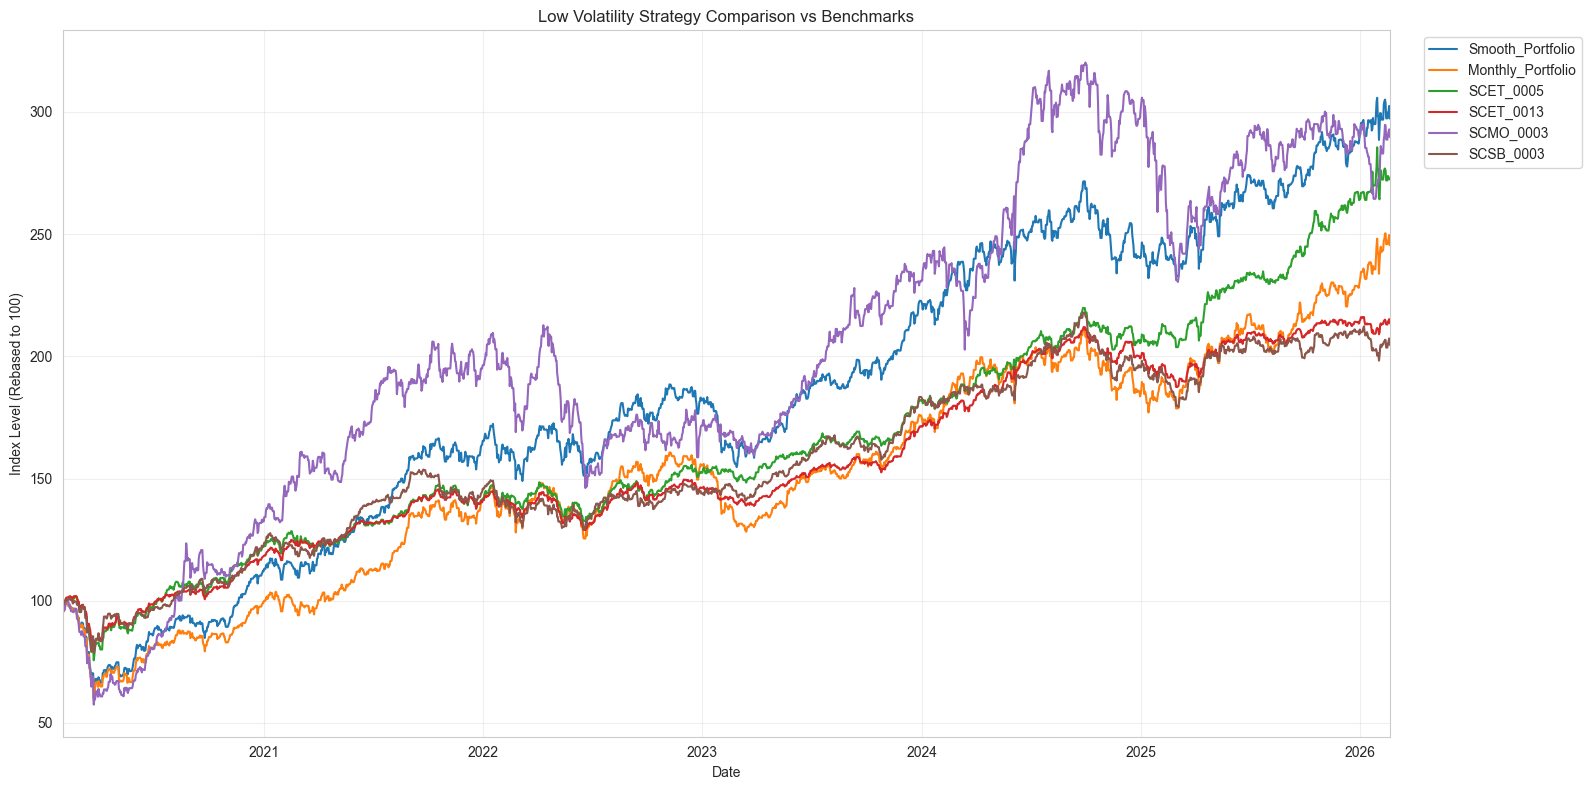

════════════════════════════════════════════════════════════════════════════════════════════════════
 PORTFOLIO & BENCHMARK PERFORMANCE COMPARISON
════════════════════════════════════════════════════════════════════════════════════════════════════
 Metric             | Smooth_Portfoli | Monthly_Portfol |       SCET_0005 |       SCET_0013 |       SCMO_0003 |       SCSB_0003
-------------------------------------------------------------------------------------------------------------------------------
 CAGR (%)           |           13.20 |           10.78 |           12.03 |            8.97 |           12.77 |            8.51
 Ann. Vol (%)       |           15.95 |           16.14 |           10.17 |            7.92 |           20.75 |           11.20
 Sharpe             |            0.86 |            0.72 |            1.17 |            1.13 |            0.69 |            0.79
 Sortino            |            1.16 |            0.96 |            1.65 |            1.54 |            0.93 | 

In [11]:
# 1. Plotting
plt.figure(figsize=(16, 8))
combined_performance.plot(ax=plt.gca(), linewidth=1.5)
plt.title('Low Volatility Strategy Comparison vs Benchmarks')
plt.ylabel('Index Level (Rebased to 100)')
plt.xlabel('Date')
plt.grid(True, alpha=0.3)

# Move the legend outside the plot so it doesn't cover the lines
plt.legend(loc='upper left', bbox_to_anchor=(1.02, 1))
plt.tight_layout()
plt.show()


# 2. Analytics Helper Function
def get_metrics(series):
    df_single = series.to_frame()
    analytics = qd.IndexAnalytics(indexDf=df_single)

    # Extract scalar values safely by casting to float
    cagr = float(analytics.getSimpleCGR().iloc[0])
    vol = float(analytics.getSimpleSTD().iloc[0])

    # Handle downside deviation (might be a Series or float)
    downside_res = analytics.getDownsideDeviation()
    if isinstance(downside_res, (pd.Series, pd.DataFrame)):
        downside = float(downside_res.iloc[0])
    else:
        downside = float(downside_res)

    daily_ret = series.pct_change().dropna()

    # Cast manual calculations to float
    sharpe = float((daily_ret.mean() * 252) / (daily_ret.std() * np.sqrt(252)))
    sortino = float((daily_ret.mean() * 252) / (downside * np.sqrt(252)))

    roll_max = series.cummax()
    md = float((series / roll_max - 1.0).min())

    return {
        "CAGR (%)": cagr * 100,
        "Ann. Vol (%)": vol * 100,
        "Sharpe": sharpe,
        "Sortino": sortino,
        "Max Drawdown (%)": md * 100
    }


# 3. Print Comparison Table dynamically for ALL columns
all_metrics = {}
for col in combined_performance.columns:
    all_metrics[col] = get_metrics(combined_performance[col])

df_metrics = pd.DataFrame(all_metrics)

print("═" * 100)
print(" PORTFOLIO & BENCHMARK PERFORMANCE COMPARISON")
print("═" * 100)

# Create a dynamic header based on the number of columns
header = f" {'Metric':<18} | " + " | ".join([f"{str(col)[:15]:>15}" for col in df_metrics.columns])
print(header)
print("-" * len(header))

# Print the values row by row
for metric in df_metrics.index:
    row_str = f" {metric:<18} | " + " | ".join([f"{df_metrics.loc[metric, col]:>15.2f}" for col in df_metrics.columns])
    print(row_str)
print("═" * 100)

In [12]:
combined_performance

,Smooth_Portfolio,Monthly_Portfolio,SCET_0005,SCET_0013,SCMO_0003,SCSB_0003
Date,,,,,,
2020-01-31,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
2020-02-01,95.744539,95.568514,98.894858,100.000000,97.803108,98.546264
2020-02-02,95.744539,95.568514,98.894858,100.000000,97.803108,98.546264
2020-02-03,96.939580,96.346468,98.546901,98.573502,96.031466,99.194247
2020-02-04,99.148453,98.713750,99.520558,99.782095,96.972124,99.884749
...,...,...,...,...,...,...
2026-02-16,299.861015,246.998996,273.772629,214.090957,290.684256,205.222388
2026-02-17,300.112399,248.013774,272.499463,214.722703,292.046110,206.047136
2026-02-18,302.423893,249.592826,272.928966,215.186937,292.847163,207.286056


In [13]:
weights_smooth

Ticker,ADANIENT,ADANIPORTS,ADANIPOWER,ASIANPAINT,AXISBANK,BAJAJ-AUTO,BAJAJFINSV,BAJFINANCE,BEL,BERGEPAINT,...,SHRIRAMFIN,SIEMENS,SUNPHARMA,TATASTEEL,TCS,TECHM,TITAN,ULTRACEMCO,VEDL,WIPRO
RebalDate,,,,,,,,,,,,,,,,,,,,,
2020-01-31,0.0,0.1,0.0,0.1,0.0,0.0,0.1,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2020-02-28,0.0,0.1,0.0,0.0,0.0,0.0,0.1,0.1,0.0,0.1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2020-03-31,0.0,0.1,0.0,0.0,0.0,0.0,0.1,0.0,0.0,0.1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.1,0.0,0.0,0.0
2020-04-30,0.0,0.1,0.0,0.0,0.0,0.0,0.1,0.0,0.0,0.1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2020-05-29,0.0,0.1,0.0,0.0,0.0,0.0,0.1,0.1,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-10-31,0.0,0.0,0.0,0.1,0.0,0.0,0.1,0.0,0.1,0.0,...,0.0,0.0,0.0,0.1,0.0,0.0,0.0,0.0,0.0,0.0
2025-11-28,0.0,0.0,0.0,0.1,0.0,0.0,0.0,0.0,0.1,0.0,...,0.0,0.0,0.0,0.1,0.0,0.0,0.0,0.0,0.1,0.0
2025-12-31,0.0,0.0,0.0,0.1,0.0,0.0,0.0,0.0,0.1,0.0,...,0.1,0.0,0.0,0.1,0.0,0.0,0.0,0.0,0.1,0.0


---
## Inverse-Volatility Weighting — Smooth Top-10

Same stock selection as **Smooth_Portfolio** (top-10 by `Vol_Regime_Smooth` each month).
Only the **weights** change: instead of equal 10% each, each stock receives a weight
proportional to the inverse of its calibrated volatility signal.

```
w_i = (1 / signal_i) / Σ(1 / signal_j)   for j in selected top-10
```

Stocks with a **lower** signal (calmer regime) receive a **higher** weight automatically.
This is the standard minimum-variance construction principle applied within the already-selected basket.

In [14]:
# ── Build inverse-vol weight matrix from the same Smooth top-10 selection ─────
SELECTION_EXCEL = r"D:\Linear Model\monthly_low_vol_selection.xlsx"

df_smooth_iv = pd.read_excel(SELECTION_EXCEL, sheet_name='Smooth_Portfolio')
df_smooth_iv['RebalDate'] = pd.to_datetime(df_smooth_iv['RebalDate'])

# Compute inverse-vol weights: w_i = (1/signal_i) / sum(1/signal_j)
def apply_inv_vol_weights(group):
    inv = 1.0 / group['Smooth_Signal']
    group = group.copy()
    group['Weight'] = inv / inv.sum()
    return group

df_smooth_iv = df_smooth_iv.groupby('RebalDate', group_keys=False).apply(apply_inv_vol_weights)

# Build weight matrix: rows=RebalDate, cols=Ticker
weights_smooth_iv = df_smooth_iv.pivot_table(
    index='RebalDate', columns='Ticker', values='Weight'
).fillna(0.0)
weights_smooth_iv.index = pd.to_datetime(weights_smooth_iv.index)

# Sanity checks
row_sums = weights_smooth_iv.sum(axis=1)
bad = (row_sums - 1.0).abs() > 0.01
print(f"weights_smooth_iv shape : {weights_smooth_iv.shape}")
print(f"Row sums — mean: {row_sums.mean():.4f}  min: {row_sums.min():.4f}  max: {row_sums.max():.4f}")
if bad.any():
    print(f"WARNING: {bad.sum()} rows don't sum to 1.0")
else:
    print("All rows sum to 1.0 ✓")

# ── Show weight distribution vs equal weight ──────────────────────────────────
all_weights_stacked = df_smooth_iv[['Smooth_Signal', 'Weight']].copy()
all_weights_stacked['Equal_Weight'] = 0.10

print(f"\nWeight distribution (across all months & stocks):")
print(f"  {'':25s}  {'Min':>8}  {'Mean':>8}  {'Max':>8}  {'Std':>8}")
print(f"  {'Inv-Vol Weight':25s}  "
      f"{all_weights_stacked['Weight'].min():>8.4f}  "
      f"{all_weights_stacked['Weight'].mean():>8.4f}  "
      f"{all_weights_stacked['Weight'].max():>8.4f}  "
      f"{all_weights_stacked['Weight'].std():>8.4f}")
print(f"  {'Equal Weight (baseline)':25s}  "
      f"{0.10:>8.4f}  {0.10:>8.4f}  {0.10:>8.4f}  {0.0:>8.4f}")

weights_smooth_iv shape : (74, 55)
Row sums — mean: 1.0000  min: 1.0000  max: 1.0000
All rows sum to 1.0 ✓

Weight distribution (across all months & stocks):
                                  Min      Mean       Max       Std
  Inv-Vol Weight               0.0297    0.1000    0.6611    0.0691
  Equal Weight (baseline)      0.1000    0.1000    0.1000    0.0000


In [15]:
# ── Backtest: Smooth_InvVol portfolio ─────────────────────────────────────────
# Drop any tickers missing from price data and re-normalise
iv_cols     = [c for c in weights_smooth_iv.columns if c in closeMergedDf.columns]
missing_iv  = [c for c in weights_smooth_iv.columns if c not in closeMergedDf.columns]
if missing_iv:
    print(f"WARNING: {len(missing_iv)} tickers missing from price data: {missing_iv}")
    weights_smooth_iv = weights_smooth_iv[iv_cols]
    weights_smooth_iv = weights_smooth_iv.div(weights_smooth_iv.sum(axis=1), axis=0).fillna(0)

rebalDates_iv = weights_smooth_iv.index
indexDates_iv = closeMergedDf.loc[rebalDates_iv[0]:].index

print("Calculating Smooth_InvVol Portfolio Index...")
indexObj_iv = qd.IndexCalculator(
    indexDates_iv.values,
    rebalDates_iv,
    weights_smooth_iv,
    closeMergedDf[weights_smooth_iv.columns]
)
df_iv = indexObj_iv.getSimpleNextDayRebalIndex(
    openPriceDf=openMergedDf[weights_smooth_iv.columns],
    highPriceDf=highMergedDf[weights_smooth_iv.columns],
    lowPriceDf=lowMergedDf[weights_smooth_iv.columns],
    indexName='Smooth_InvVol'
)[0]

# Merge with existing combined_performance
combined_iv = combined_performance.join(df_iv, how='left').ffill().dropna()
combined_iv = combined_iv.astype(float)
print(f"Combined shape: {combined_iv.shape}")
print(f"Columns: {list(combined_iv.columns)}")

Calculating Smooth_InvVol Portfolio Index...
Combined shape: (2213, 7)
Columns: ['Smooth_Portfolio', 'Monthly_Portfolio', 'SCET_0005', 'SCET_0013', 'SCMO_0003', 'SCSB_0003', 'Smooth_InvVol']


 PERFORMANCE COMPARISON  (Smooth_InvVol added)
 Metric             | Smooth_Portfoli | Monthly_Portfol |       SCET_0005 |       SCET_0013 |       SCMO_0003 |       SCSB_0003 |   Smooth_InvVol
-------------------------------------------------------------------------------------------------------------------------------------------------
 CAGR (%)           |           13.20 |           10.78 |           12.03 |            8.97 |           12.77 |            8.51 |           15.45
 Ann. Vol (%)       |           15.95 |           16.14 |           10.17 |            7.92 |           20.75 |           11.20 |           16.42
 Sharpe             |            0.86 |            0.72 |            1.17 |            1.13 |            0.69 |            0.79 |            0.96
 Sortino            |            1.16 |            0.96 |            1.65 |            1.54 |            0.93 |            1.12 |            1.29
 Max Drawdown (%)   |          -39.98 |          -41.09 |          -25.53 |  

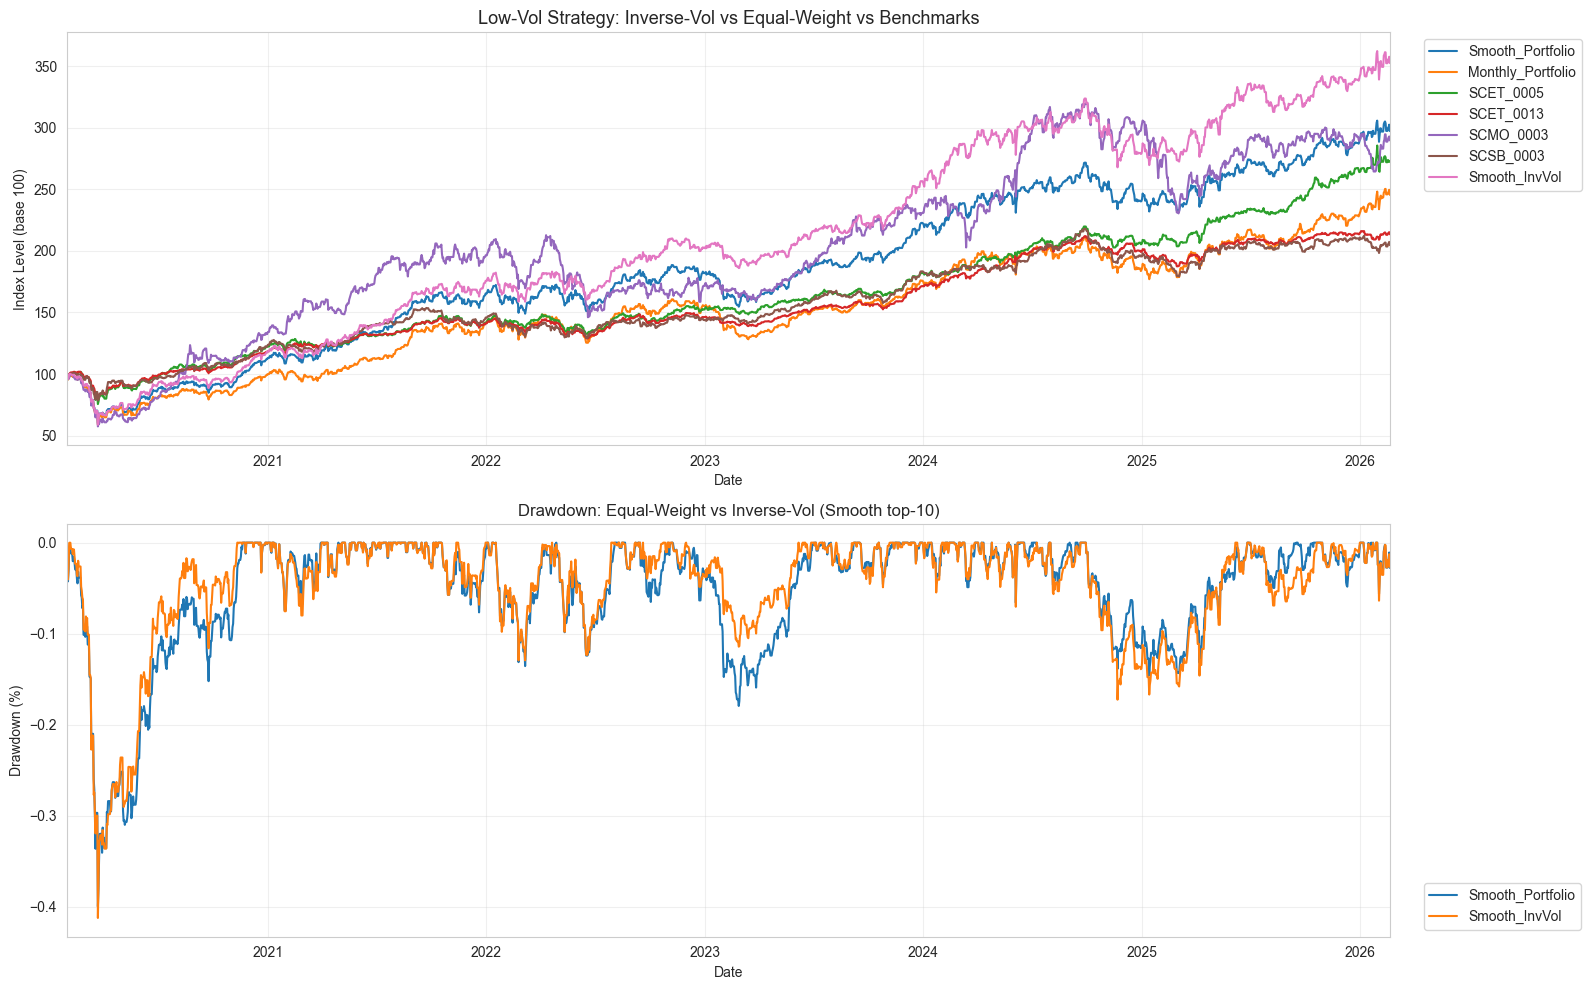

In [16]:
# ── Performance metrics: InvVol vs EqualWeight vs Benchmarks ──────────────────
def get_metrics(series):
    df_single  = series.to_frame()
    analytics  = qd.IndexAnalytics(indexDf=df_single)
    cagr       = float(analytics.getSimpleCGR().iloc[0])
    vol        = float(analytics.getSimpleSTD().iloc[0])
    downside_res = analytics.getDownsideDeviation()
    downside   = float(downside_res.iloc[0] if isinstance(downside_res, (pd.Series, pd.DataFrame)) else downside_res)
    daily_ret  = series.pct_change().dropna()
    sharpe     = float((daily_ret.mean() * 252) / (daily_ret.std() * np.sqrt(252)))
    sortino    = float((daily_ret.mean() * 252) / (downside * np.sqrt(252)))
    md         = float((series / series.cummax() - 1.0).min())
    return {'CAGR (%)': cagr * 100, 'Ann. Vol (%)': vol * 100,
            'Sharpe': sharpe, 'Sortino': sortino, 'Max Drawdown (%)': md * 100}

all_metrics = {col: get_metrics(combined_iv[col]) for col in combined_iv.columns}
df_metrics  = pd.DataFrame(all_metrics)

col_width = 17
sep = '=' * (20 + col_width * len(df_metrics.columns))
print(sep)
print(' PERFORMANCE COMPARISON  (Smooth_InvVol added)')
print(sep)
header = f" {'Metric':<18} | " + ' | '.join(
    [f"{str(c)[:col_width-2]:>{col_width-2}}" for c in df_metrics.columns])
print(header)
print('-' * len(header))
for metric in df_metrics.index:
    row = f" {metric:<18} | " + ' | '.join(
        [f"{df_metrics.loc[metric, c]:>{col_width-2}.2f}" for c in df_metrics.columns])
    print(row)
print(sep)

# ── Plot ───────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# Top: index levels
combined_iv.plot(ax=axes[0], linewidth=1.5)
axes[0].set_title('Low-Vol Strategy: Inverse-Vol vs Equal-Weight vs Benchmarks', fontsize=13)
axes[0].set_ylabel('Index Level (base 100)')
axes[0].legend(loc='upper left', bbox_to_anchor=(1.02, 1))
axes[0].grid(True, alpha=0.3)

# Bottom: drawdown
dd = combined_iv.div(combined_iv.cummax()) - 1.0
dd[['Smooth_Portfolio', 'Smooth_InvVol']].plot(ax=axes[1], linewidth=1.5)
axes[1].set_title('Drawdown: Equal-Weight vs Inverse-Vol (Smooth top-10)', fontsize=12)
axes[1].set_ylabel('Drawdown (%)')
axes[1].legend(loc='lower left', bbox_to_anchor=(1.02, 0))
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## Realized-Volatility Weighting — Smooth Top-10

Same stock selection as **Smooth_Portfolio** (top-10 by `Vol_Regime_Smooth`).

Weights are now computed from **realized volatility** (annualized 63-day rolling stddev of daily returns) rather than the regime signal:

```
σ_i  = std(daily_returns[-63:]) × √252      ← realized vol at rebal date
w_i  = (1 / σ_i) / Σ(1 / σ_j)              ← inverse-vol weight
```

This directly minimizes portfolio variance (under equal-correlation assumption) because the weighting denominator is the actual volatility of each stock's returns — not a relative regime indicator.

In [17]:
# ── Pre-compute 63-day rolling realized vol for every ticker ──────────────────
LOOKBACK = 63   # ~3 months of trading days

daily_returns = closeMergedDf.pct_change()   # already calendar-aligned
realized_vol  = daily_returns.rolling(LOOKBACK).std() * np.sqrt(252)  # annualised

# ── Load the same Smooth top-10 selection ─────────────────────────────────────
SELECTION_EXCEL = r"D:\Linear Model\monthly_low_vol_selection.xlsx"

df_smooth_rv = pd.read_excel(SELECTION_EXCEL, sheet_name='Smooth_Portfolio')
df_smooth_rv['RebalDate'] = pd.to_datetime(df_smooth_rv['RebalDate'])

# ── For each rebal date look up realized vol and compute weights ───────────────
weight_rows = []

for rebal_date, group in df_smooth_rv.groupby('RebalDate'):
    tickers = group['Ticker'].tolist()

    # Find the closest price date <= rebal_date to look up realized vol
    available_dates = realized_vol.index[realized_vol.index <= rebal_date]
    if len(available_dates) == 0:
        continue
    lookup_date = available_dates[-1]

    rvol = {}
    for t in tickers:
        if t in realized_vol.columns:
            v = realized_vol.loc[lookup_date, t]
            if pd.notna(v) and v > 0:
                rvol[t] = v

    if len(rvol) < 2:
        # Fallback to equal weight if realized vol unavailable
        for t in tickers:
            weight_rows.append({'RebalDate': rebal_date, 'Ticker': t,
                                 'RealizedVol': np.nan, 'Weight': 1.0 / len(tickers)})
        continue

    inv_sum = sum(1.0 / v for v in rvol.values())
    for t in tickers:
        if t in rvol:
            w = (1.0 / rvol[t]) / inv_sum
        else:
            w = 0.0   # missing price data — excluded, others renorm below
        weight_rows.append({'RebalDate': rebal_date, 'Ticker': t,
                             'RealizedVol': rvol.get(t, np.nan), 'Weight': w})

df_smooth_rv_w = pd.DataFrame(weight_rows)

# Re-normalise any rows where some tickers had missing prices
df_smooth_rv_w['Weight'] = df_smooth_rv_w.groupby('RebalDate')['Weight'].transform(
    lambda x: x / x.sum() if x.sum() > 0 else x
)

# ── Build weight matrix ────────────────────────────────────────────────────────
weights_smooth_rv = df_smooth_rv_w.pivot_table(
    index='RebalDate', columns='Ticker', values='Weight'
).fillna(0.0)
weights_smooth_rv.index = pd.to_datetime(weights_smooth_rv.index)

# Sanity check
row_sums = weights_smooth_rv.sum(axis=1)
print(f"weights_smooth_rv shape : {weights_smooth_rv.shape}")
print(f"Row sums — mean: {row_sums.mean():.4f}  min: {row_sums.min():.4f}  max: {row_sums.max():.4f}")

# ── Weight distribution comparison ────────────────────────────────────────────
rv_w = df_smooth_rv_w['Weight'].dropna()
print(f"\nRealized-vol weight distribution (across all months & stocks):")
print(f"  Min: {rv_w.min():.4f}   Mean: {rv_w.mean():.4f}   Max: {rv_w.max():.4f}   Std: {rv_w.std():.4f}")
print(f"  Regime-sig InvVol  — Mean: {all_weights_stacked['Weight'].mean():.4f}   Std: {all_weights_stacked['Weight'].std():.4f}")
print(f"  Equal-weight       — Mean: 0.1000   Std: 0.0000")

weights_smooth_rv shape : (74, 55)
Row sums — mean: 1.0000  min: 1.0000  max: 1.0000

Realized-vol weight distribution (across all months & stocks):
  Min: 0.0155   Mean: 0.1000   Max: 0.1965   Std: 0.0241
  Regime-sig InvVol  — Mean: 0.1000   Std: 0.0691
  Equal-weight       — Mean: 0.1000   Std: 0.0000


In [18]:
# ── Backtest: Smooth_RealizedVol portfolio ────────────────────────────────────
rv_cols    = [c for c in weights_smooth_rv.columns if c in closeMergedDf.columns]
missing_rv = [c for c in weights_smooth_rv.columns if c not in closeMergedDf.columns]
if missing_rv:
    print(f"WARNING: {len(missing_rv)} tickers missing from price data: {missing_rv}")
    weights_smooth_rv = weights_smooth_rv[rv_cols]
    weights_smooth_rv = weights_smooth_rv.div(weights_smooth_rv.sum(axis=1), axis=0).fillna(0)

rebalDates_rv = weights_smooth_rv.index
indexDates_rv = closeMergedDf.loc[rebalDates_rv[0]:].index

print("Calculating Smooth_RealizedVol Portfolio Index...")
indexObj_rv = qd.IndexCalculator(
    indexDates_rv.values,
    rebalDates_rv,
    weights_smooth_rv,
    closeMergedDf[weights_smooth_rv.columns]
)
df_rv = indexObj_rv.getSimpleNextDayRebalIndex(
    openPriceDf=openMergedDf[weights_smooth_rv.columns],
    highPriceDf=highMergedDf[weights_smooth_rv.columns],
    lowPriceDf=lowMergedDf[weights_smooth_rv.columns],
    indexName='Smooth_RealizedVol'
)[0]

# Merge with all existing portfolios + benchmarks
combined_all = combined_iv.join(df_rv, how='left').ffill().dropna().astype(float)
print(f"Combined shape: {combined_all.shape}")
print(f"Columns: {list(combined_all.columns)}")

Calculating Smooth_RealizedVol Portfolio Index...
Combined shape: (2213, 8)
Columns: ['Smooth_Portfolio', 'Monthly_Portfolio', 'SCET_0005', 'SCET_0013', 'SCMO_0003', 'SCSB_0003', 'Smooth_InvVol', 'Smooth_RealizedVol']


 FINAL COMPARISON — Equal-Weight vs InvVol (Regime) vs InvVol (Realized)
 Metric             | Smooth_Portfoli | Monthly_Portfol |       SCET_0005 |       SCET_0013 |       SCMO_0003 |       SCSB_0003 |   Smooth_InvVol | Smooth_Realized
-------------------------------------------------------------------------------------------------------------------------------------------------------------------
 CAGR (%)           |           13.20 |           10.78 |           12.03 |            8.97 |           12.77 |            8.51 |           15.45 |           12.46
 Ann. Vol (%)       |           15.95 |           16.14 |           10.17 |            7.92 |           20.75 |           11.20 |           16.42 |           15.23
 Sharpe             |            0.86 |            0.72 |            1.17 |            1.13 |            0.69 |            0.79 |            0.96 |            0.85
 Sortino            |            1.16 |            0.96 |            1.65 |            1.54 |            0.

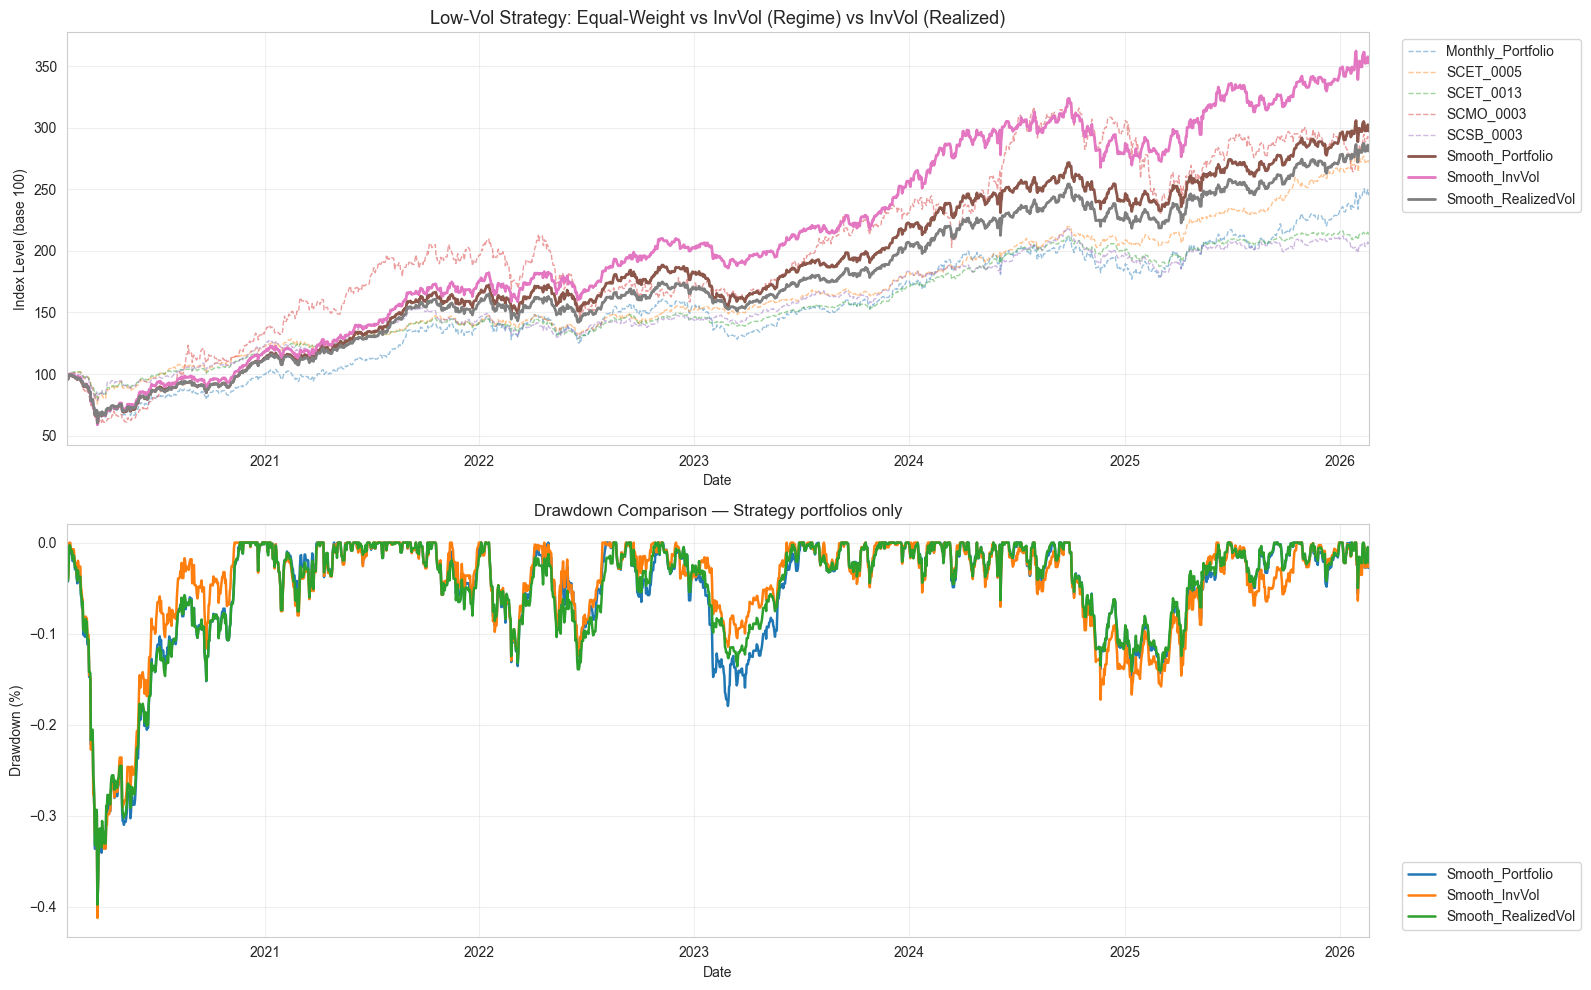

In [19]:
# ── Final metrics table: all three weighting schemes + benchmarks ─────────────
all_metrics_final = {col: get_metrics(combined_all[col]) for col in combined_all.columns}
df_metrics_final  = pd.DataFrame(all_metrics_final)

col_width = 17
sep = '=' * (20 + col_width * len(df_metrics_final.columns))
print(sep)
print(' FINAL COMPARISON — Equal-Weight vs InvVol (Regime) vs InvVol (Realized)')
print(sep)
header = f" {'Metric':<18} | " + ' | '.join(
    [f"{str(c)[:col_width-2]:>{col_width-2}}" for c in df_metrics_final.columns])
print(header)
print('-' * len(header))
for metric in df_metrics_final.index:
    row = f" {metric:<18} | " + ' | '.join(
        [f"{df_metrics_final.loc[metric, c]:>{col_width-2}.2f}" for c in df_metrics_final.columns])
    print(row)
print(sep)

# ── Plot: index level + drawdown ──────────────────────────────────────────────
strategy_cols   = ['Smooth_Portfolio', 'Smooth_InvVol', 'Smooth_RealizedVol']
benchmark_cols  = [c for c in combined_all.columns if c not in strategy_cols]

fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# Index levels — strategies highlighted, benchmarks muted
for col in benchmark_cols:
    combined_all[col].plot(ax=axes[0], linewidth=1.0, alpha=0.45, linestyle='--', label=col)
for col in strategy_cols:
    combined_all[col].plot(ax=axes[0], linewidth=2.0, label=col)

axes[0].set_title('Low-Vol Strategy: Equal-Weight vs InvVol (Regime) vs InvVol (Realized)', fontsize=13)
axes[0].set_ylabel('Index Level (base 100)')
axes[0].legend(loc='upper left', bbox_to_anchor=(1.02, 1))
axes[0].grid(True, alpha=0.3)

# Drawdown — strategies only
dd_all = combined_all[strategy_cols].div(combined_all[strategy_cols].cummax()) - 1.0
dd_all.plot(ax=axes[1], linewidth=1.8)
axes[1].set_title('Drawdown Comparison — Strategy portfolios only', fontsize=12)
axes[1].set_ylabel('Drawdown (%)')
axes[1].legend(loc='lower left', bbox_to_anchor=(1.02, 0))
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [22]:
combined_all

,Smooth_Portfolio,Monthly_Portfolio,SCET_0005,SCET_0013,SCMO_0003,SCSB_0003,Smooth_InvVol,Smooth_RealizedVol
Date,,,,,,,,
2020-01-31,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
2020-02-01,95.744539,95.568514,98.894858,100.000000,97.803108,98.546264,95.965161,95.862995
2020-02-02,95.744539,95.568514,98.894858,100.000000,97.803108,98.546264,95.965161,95.862995
2020-02-03,96.939580,96.346468,98.546901,98.573502,96.031466,99.194247,97.331235,97.179885
2020-02-04,99.148453,98.713750,99.520558,99.782095,96.972124,99.884749,99.964875,99.306250
...,...,...,...,...,...,...,...,...
2026-02-16,299.861015,246.998996,273.772629,214.090957,290.684256,205.222388,355.211525,283.698963
2026-02-17,300.112399,248.013774,272.499463,214.722703,292.046110,206.047136,355.168785,284.080966
2026-02-18,302.423893,249.592826,272.928966,215.186937,292.847163,207.286056,357.536825,285.923674
